<div class="alert alert-info alert-warning" style="background-color: navy; color: black; text-align: center;">
    <h1><span style="color: white;">Ozan MÖHÜRCÜ</span></h1>
    <h1><span style="color: white;">Data Analyst | Data Scientist</span></h1>

<div style="margin-top: 20px; font-family: Arial, sans-serif; text-align: center;">
        <a href="https://www.linkedin.com/in/ozanmhrc/" style="text-decoration: none; color: #fff; margin-right: 10px;">
            <span style="background-color: #0077B5; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">LinkedIn</span>
        </a>
        <a href="https://github.com/Ozan-Mohurcu" style="text-decoration: none; color: #fff; margin-right: 10px;">
            <span style="background-color: #333; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">GitHub</span>
        </a>
        <a href="https://ozan-mohurcu.github.io/" style="text-decoration: none; color: #fff;">
            <span style="background-color: #28a745; padding: 8px 20px; border-radius: 5px; font-size: 14px; display: inline-block; width: 120px; text-align: center;">Portfolio</span>
        </a>
    </div>
</div>

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Libraries and Utilities
</h1>

Environment Setup:
- **Data Manipulation:** pandas, numpy for efficient data processing
- **Visualization:** matplotlib, seaborn for professional graphics
- **Analysis Tools:** collections for frequency analysis
- **Configuration:** Custom color scheme (gray, navy) and warning suppression

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# Color palette
colors = ['gray', 'navy']

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette(colors)

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Data Loading
</h1>

**Dataset Overview:**
- **Source:** Netflix titles dataset containing movies and TV shows
- **Format:** CSV file with comprehensive content metadata
- **Initial Inspection:** First 5 records to understand data structure
- **Preparation:** Setting up for exploratory data analysis

In [2]:
df = pd.read_csv('/kaggle/input/netflix-shows/netflix_titles.csv')

df.head(5) 

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Data Inspection
</h1>

**Key Metrics:**
- **Total Records:** Complete count of Netflix titles in dataset
- **Features:** Number of columns and their data types
- **Memory Usage:** Dataset size and efficiency metrics
- **Data Quality:** Initial assessment of completeness

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Missing Values Analysis
</h1>

**Data Quality Assessment:**
- **Completeness Check:** Identifying columns with null values
- **Impact Evaluation:** Understanding missing data distribution
- **Decision Framework:** Preparing strategy for data cleaning
- **Visual Summary:** Bar chart showing complete vs missing records

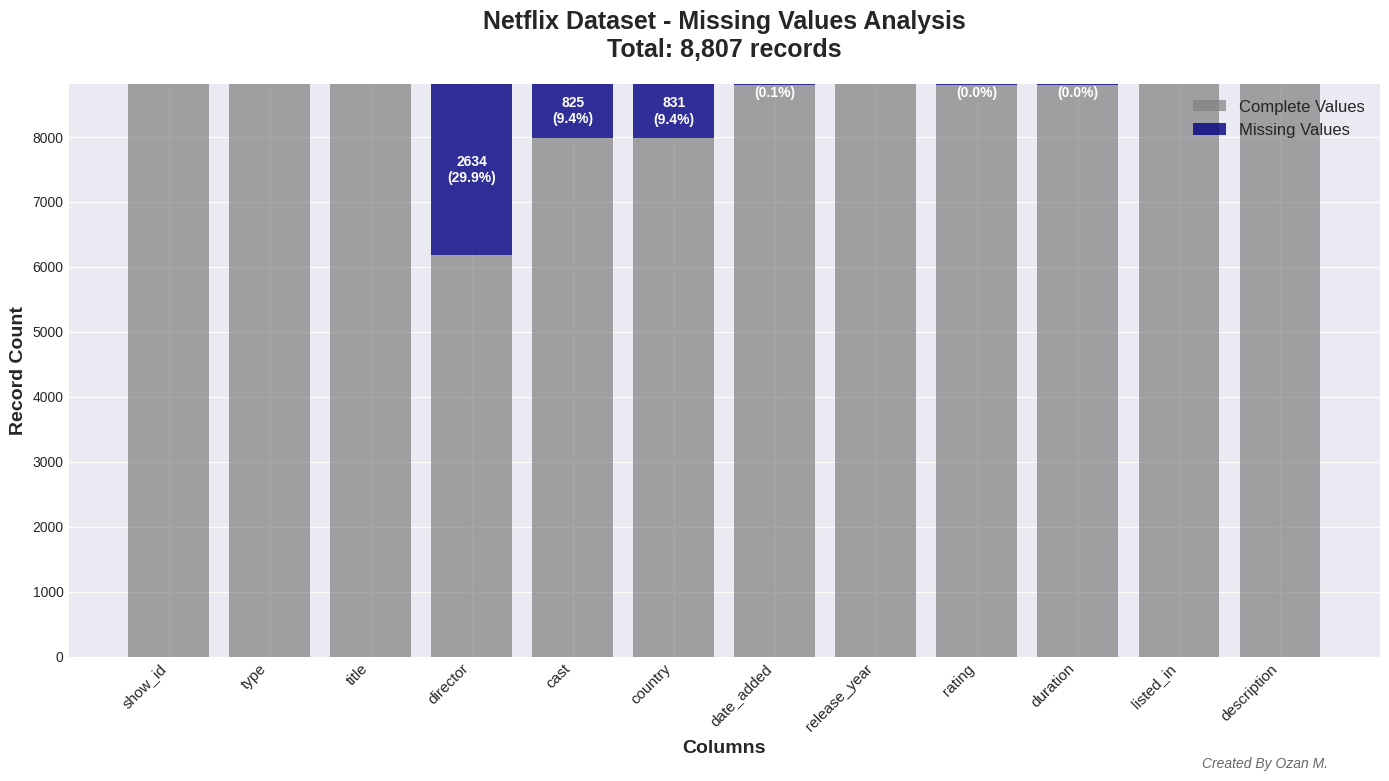

In [5]:
missing = df.isnull().sum()
complete = len(df) - missing
total = len(df)

plt.figure(figsize=(14, 8))
x = np.arange(len(df.columns))

plt.bar(x, complete, color='gray', alpha=0.7, label='Complete Values')
plt.bar(x, missing, bottom=complete, color='navy', alpha=0.8, label='Missing Values')

plt.title(f'Netflix Dataset - Missing Values Analysis\nTotal: {total:,} records', 
          fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Columns', fontsize=14, fontweight='bold')
plt.ylabel('Record Count', fontsize=14, fontweight='bold')
plt.xticks(x, df.columns, rotation=45, ha='right', fontsize=11)
plt.legend(fontsize=12, loc='upper right')

for i, (miss, comp) in enumerate(zip(missing, complete)):
    if miss > 0:
        pct = (miss/total)*100
        plt.text(i, comp + miss/2, f'{miss}\n({pct:.1f}%)', 
                ha='center', va='center', color='white', fontweight='bold', fontsize=10)

plt.text(0.96, -0.2, 'Created By Ozan M.', 
         transform=plt.gca().transAxes, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Outlier Detection
</h1>

**Anomaly Identification:**
- **Release Year:** Checking for unrealistic or erroneous dates
- **Duration Analysis:** Identifying extreme content lengths
- **Statistical Boundaries:** Using IQR method for outlier detection
- **Data Validation:** Ensuring logical consistency in numeric fields

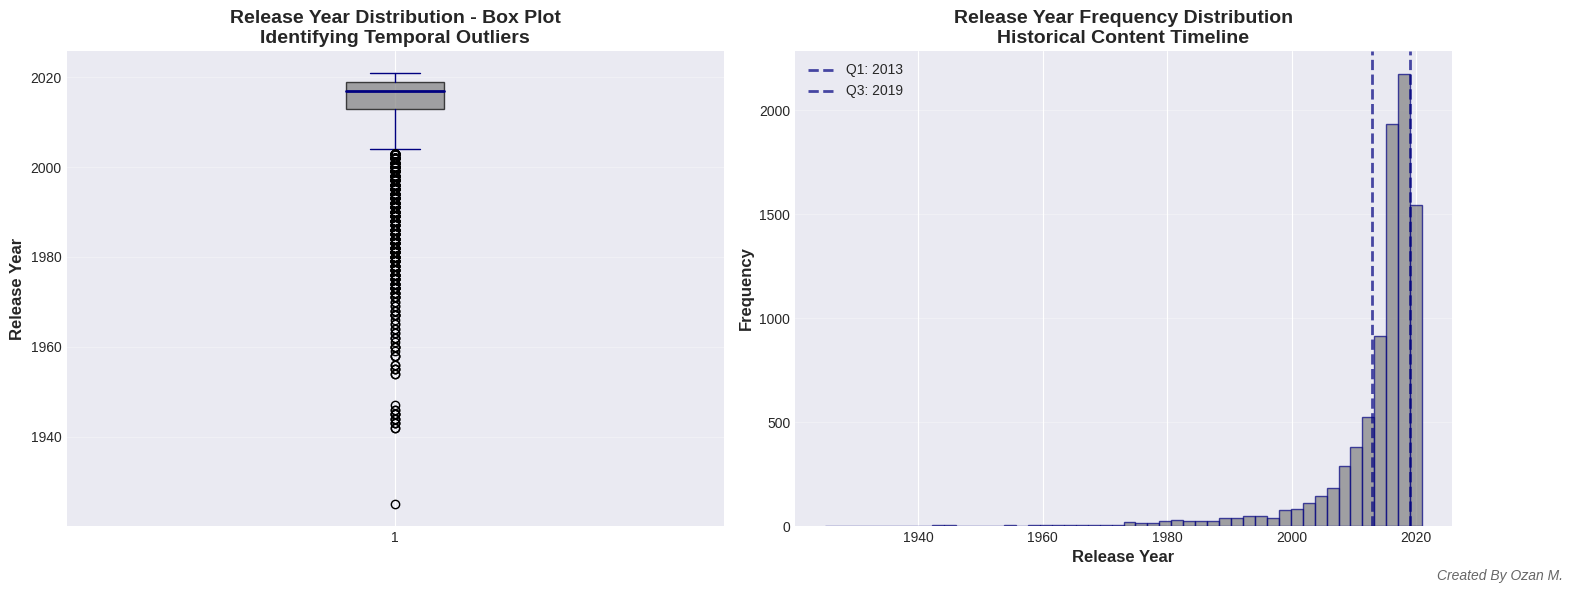

In [6]:
Q1 = df['release_year'].quantile(0.25)
Q3 = df['release_year'].quantile(0.75)
IQR = Q3 - Q1
outlier_mask = (df['release_year'] < Q1 - 1.5*IQR) | (df['release_year'] > Q3 + 1.5*IQR)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot
axes[0].boxplot(df['release_year'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='gray', alpha=0.7),
                medianprops=dict(color='navy', linewidth=2),
                whiskerprops=dict(color='navy'),
                capprops=dict(color='navy'))
axes[0].set_title('Release Year Distribution - Box Plot\nIdentifying Temporal Outliers', 
                  fontsize=14, fontweight='bold')
axes[0].set_ylabel('Release Year', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Histogram
axes[1].hist(df['release_year'].dropna(), bins=50, color='gray', alpha=0.7, edgecolor='navy')
axes[1].axvline(Q1, color='navy', linestyle='--', linewidth=2, label=f'Q1: {Q1:.0f}', alpha=0.7)
axes[1].axvline(Q3, color='navy', linestyle='--', linewidth=2, label=f'Q3: {Q3:.0f}', alpha=0.7)
axes[1].set_title('Release Year Frequency Distribution\nHistorical Content Timeline', 
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Release Year', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Missing Data Treatment
</h1>
 
**Data Imputation Strategy:**
- **Director/Cast:** Fill with 'Unknown' to preserve records
- **Country:** Impute with 'Not Specified' for missing locations
- **Date Added:** Forward fill strategy based on temporal patterns
- **Rating:** Use mode imputation for categorical consistency

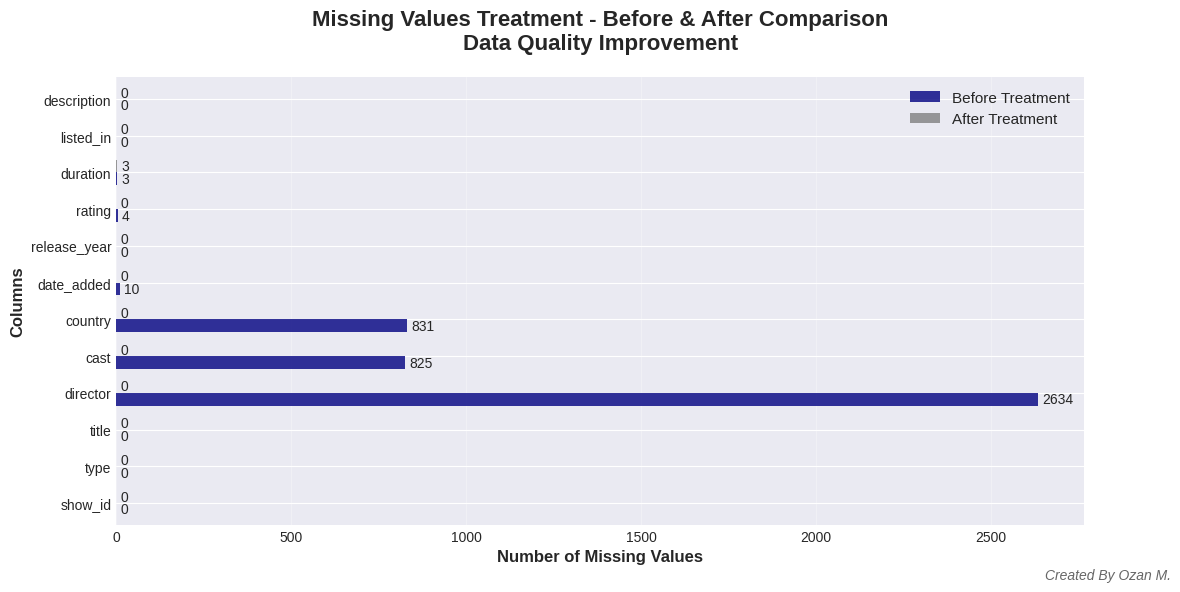

In [7]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Not Specified')
df['date_added'] = df['date_added'].fillna('Not Available')
df['rating'] = df['rating'].fillna(df['rating'].mode()[0] if not df['rating'].mode().empty else 'Not Rated')

# Verify
missing_after = df.isnull().sum()

fig, ax = plt.subplots(figsize=(12, 6))
comparison = pd.DataFrame({'Before': missing, 'After': missing_after})
comparison.plot(kind='barh', ax=ax, color=['navy', 'gray'], alpha=0.8, width=0.7)

ax.set_title('Missing Values Treatment - Before & After Comparison\nData Quality Improvement', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Missing Values', fontsize=12, fontweight='bold')
ax.set_ylabel('Columns', fontsize=12, fontweight='bold')
ax.legend(['Before Treatment', 'After Treatment'], fontsize=11, loc='upper right')
ax.grid(axis='x', alpha=0.3)

for container in ax.containers:
    ax.bar_label(container, fontsize=10, padding=3)

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Content Type Distribution
</h1>

**Platform Content Mix Analysis:**
- **Movies vs TV Shows:** Understanding Netflix's content strategy and balance between formats
- **Strategic Insights:** TV shows indicate long-term viewer engagement while movies attract broader audiences
- **Business Implications:** Content type ratio reveals platform positioning in streaming market

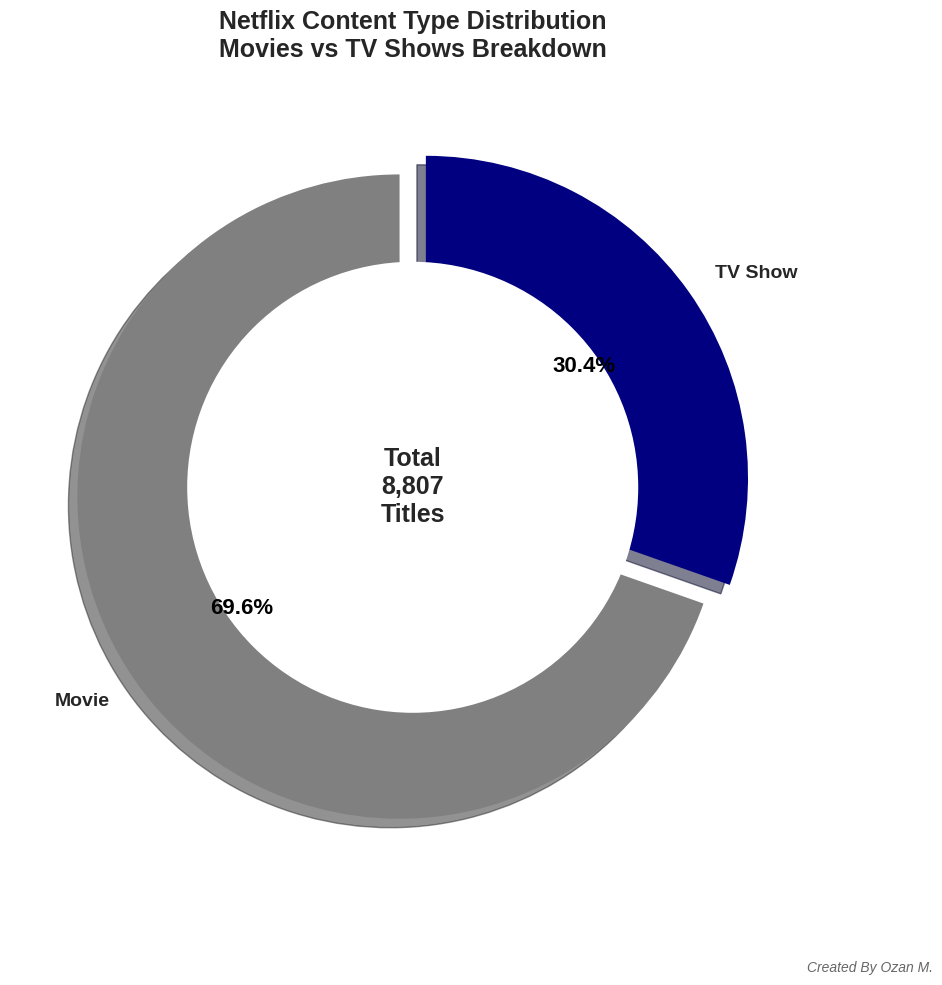

In [8]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(type_counts, 
                                    labels=type_counts.index,
                                    autopct='%1.1f%%',
                                    startangle=90,
                                    colors=colors,
                                    explode=(0.05, 0.05),
                                    shadow=True,
                                    textprops={'fontsize': 14, 'fontweight': 'bold'})

for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontsize(16)

centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

ax.text(0, 0, f'Total\n{len(df):,}\nTitles', 
        ha='center', va='center', fontsize=18, fontweight='bold')

plt.title('Netflix Content Type Distribution\nMovies vs TV Shows Breakdown', 
          fontsize=18, fontweight='bold', pad=20)

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Top Content Producing Countries
 </h1>

**Geographic Content Analysis:**
- **Production Hubs:** United States dominates with largest content library reflecting Hollywood's global influence
- **International Markets:** India, UK, and Canada show strong presence indicating Netflix's global expansion strategy
- **Market Diversity:** Top 15 countries represent varied cultural content appealing to worldwide audiences

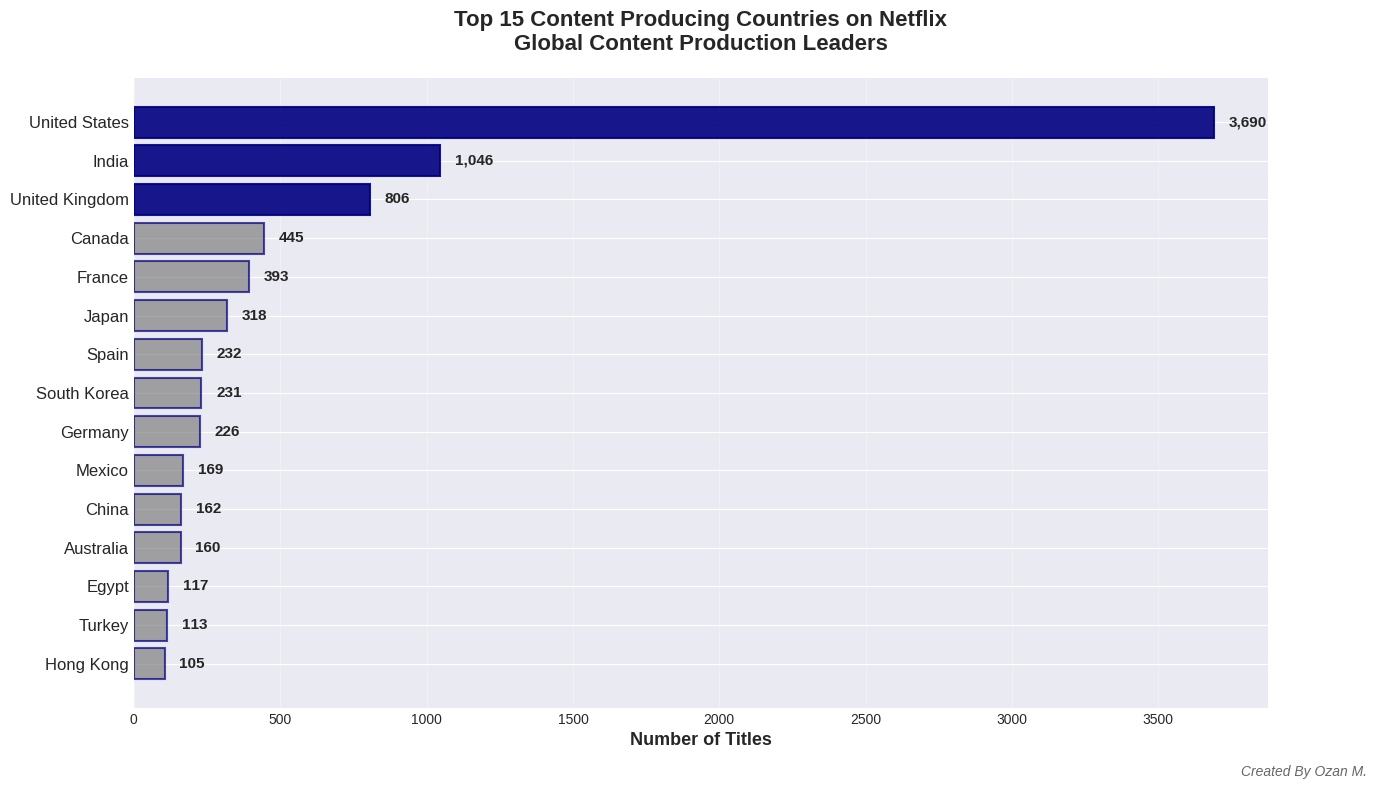

In [9]:
countries = []
for country_str in df['country'].dropna():
    if country_str != 'Not Specified':
        countries.extend([c.strip() for c in country_str.split(',')])

country_counts = pd.Series(countries).value_counts().head(15)

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(range(len(country_counts)), country_counts.values, color='gray', alpha=0.7, edgecolor='navy', linewidth=1.5)

for i, bar in enumerate(bars):
    if i < 3:
        bar.set_color('navy')
        bar.set_alpha(0.9)

ax.set_yticks(range(len(country_counts)))
ax.set_yticklabels(country_counts.index, fontsize=12)
ax.set_xlabel('Number of Titles', fontsize=13, fontweight='bold')
ax.set_title('Top 15 Content Producing Countries on Netflix\nGlobal Content Production Leaders', 
             fontsize=16, fontweight='bold', pad=20)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(country_counts.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=11, fontweight='bold')

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Content Addition Timeline
</h1>

**Growth Trajectory Analysis:**
- **Expansion Phase:** Sharp increase in content additions from 2015-2019 shows Netflix's aggressive growth period
- **Peak Activity:** 2019 marks the highest content addition rate reflecting platform maturity and market competition
- **Recent Trends:** Stabilization after 2020 suggests strategic content curation over volume-based approach

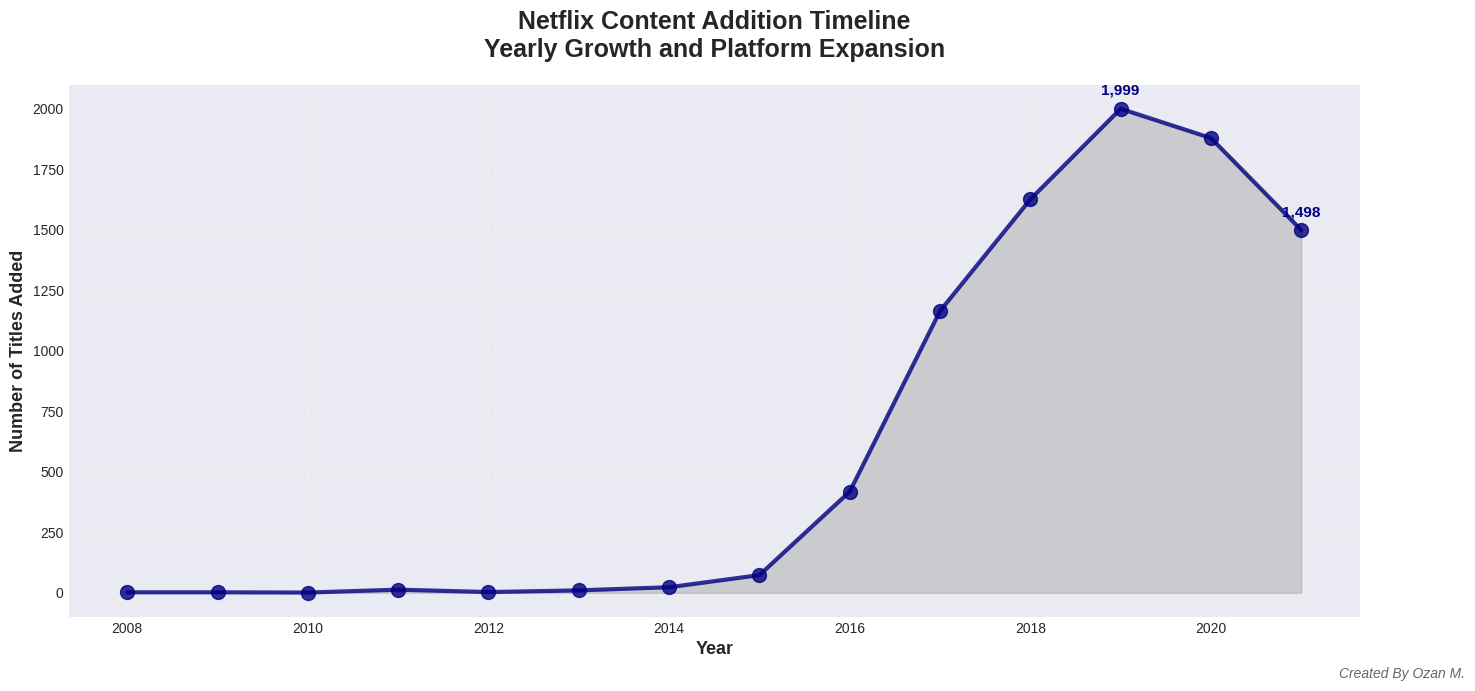

In [10]:
df['year_added'] = pd.to_datetime(df['date_added'], errors='coerce').dt.year
yearly_additions = df['year_added'].value_counts().sort_index().dropna()

fig, ax = plt.subplots(figsize=(15, 7))
ax.plot(yearly_additions.index, yearly_additions.values, 
        marker='o', linewidth=3, markersize=10, color='navy', alpha=0.8)
ax.fill_between(yearly_additions.index, yearly_additions.values, alpha=0.3, color='gray')

ax.set_title('Netflix Content Addition Timeline\nYearly Growth and Platform Expansion', 
             fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Titles Added', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, linestyle='--')

for x, y in zip(yearly_additions.index, yearly_additions.values):
    if x == yearly_additions.idxmax() or x == yearly_additions.index[-1]:
        ax.annotate(f'{int(y):,}', xy=(x, y), xytext=(0, 10), 
                   textcoords='offset points', ha='center', fontsize=11, 
                   fontweight='bold', color='navy')

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
 Content Rating Distribution
</h1>

**Audience Targeting Strategy:**
- **Mature Content Focus:** TV-MA and TV-14 ratings dominate showing Netflix targets adult and teenage demographics
- **Family Content:** Moderate presence of TV-PG and TV-Y indicates balanced portfolio for family viewing
- **Strategic Positioning:** Rating distribution reflects premium content strategy appealing to subscription-paying adults

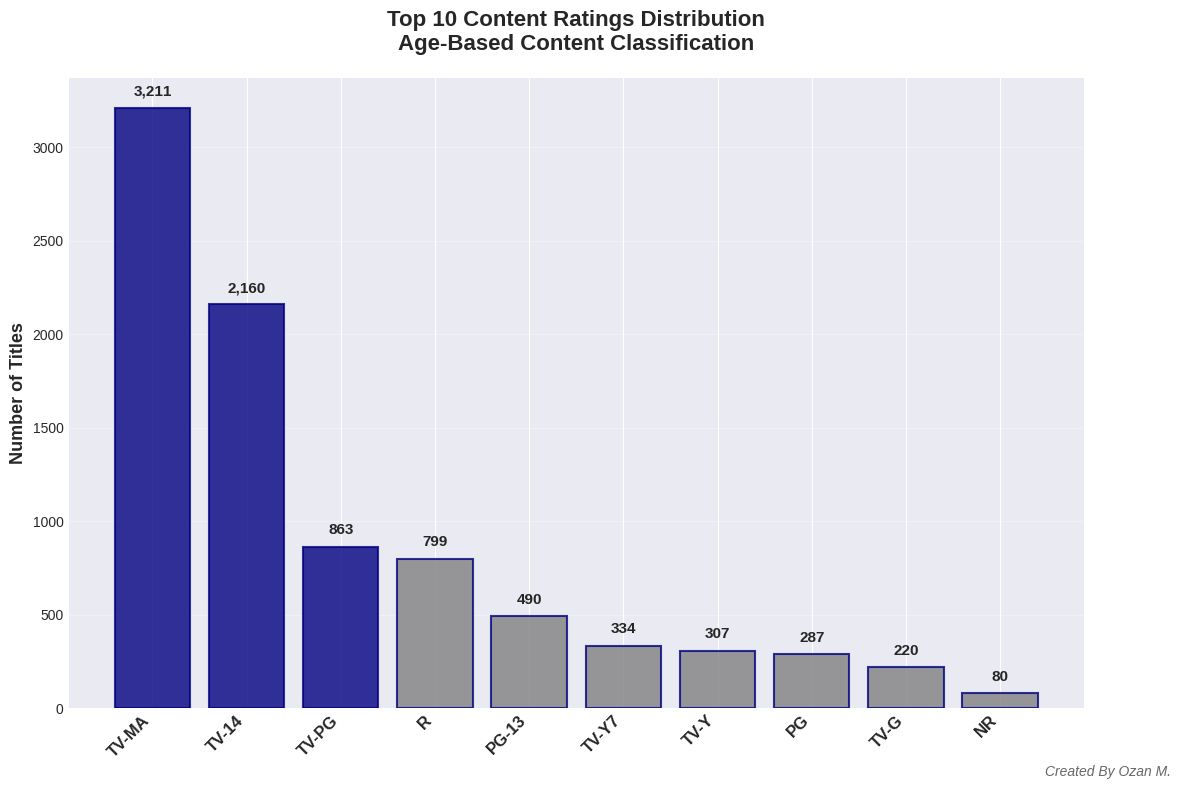

In [11]:
rating_counts = df['rating'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(12, 8))
bars = ax.bar(range(len(rating_counts)), rating_counts.values, 
              color=['navy' if i < 3 else 'gray' for i in range(len(rating_counts))], 
              alpha=0.8, edgecolor='navy', linewidth=1.5)

ax.set_xticks(range(len(rating_counts)))
ax.set_xticklabels(rating_counts.index, fontsize=12, fontweight='bold', rotation=45, ha='right')
ax.set_ylabel('Number of Titles', fontsize=13, fontweight='bold')
ax.set_title('Top 10 Content Ratings Distribution\nAge-Based Content Classification', 
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='y', alpha=0.3)

for i, (bar, v) in enumerate(zip(bars, rating_counts.values)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 50,
            f'{v:,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

 <h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Popular Genres Analysis
</h1>

**Content Category Insights:**
- **Genre Hierarchy:** International content and dramas lead showing Netflix's global reach and storytelling focus
- **Comedy Prominence:** High comedy presence indicates platform's entertainment-first approach for viewer retention
- **Genre Diversity:** Wide variety from documentaries to thrillers demonstrates comprehensive content strategy

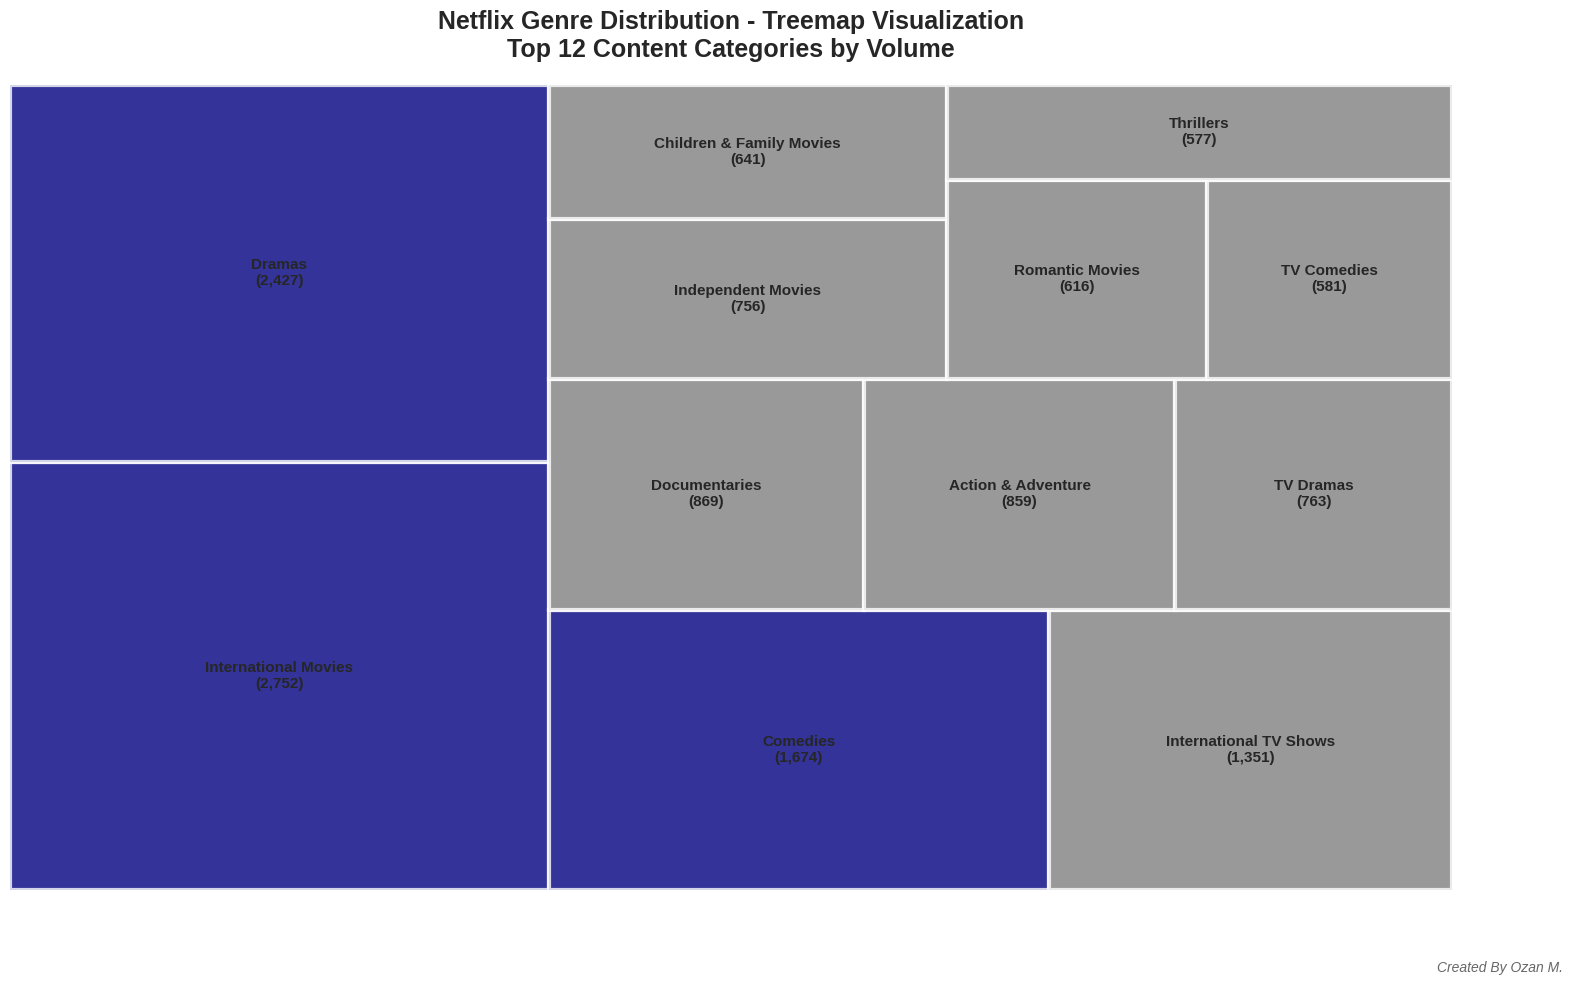

In [12]:
genres = []
for genre_str in df['listed_in'].dropna():
    genres.extend([g.strip() for g in genre_str.split(',')])

genre_counts = pd.Series(genres).value_counts().head(12)

fig = plt.figure(figsize=(16, 10))
ax = fig.add_subplot(111)

sizes = genre_counts.values
labels = [f'{label}\n({count:,})' for label, count in zip(genre_counts.index, genre_counts.values)]

import squarify

color_palette = ['navy' if i < 3 else 'gray' for i in range(len(genre_counts))]

squarify.plot(sizes=sizes, label=labels, alpha=0.8, 
              color=color_palette, edgecolor='white', linewidth=3, text_kwargs={'fontsize':11, 'fontweight':'bold'})

plt.title('Netflix Genre Distribution - Treemap Visualization\nTop 12 Content Categories by Volume', 
          fontsize=18, fontweight='bold', pad=20)
plt.axis('off')

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
Movie Duration Analysis
</h1>

 **Content Length Patterns:**
- **Standard Duration:** Most movies cluster around 90-100 minutes following traditional theatrical runtime norms
- **Diversity Range:** Wide distribution from short films to extended features shows varied content offerings
- **Peak Preference:** 90-110 minute window represents optimal viewer engagement duration for streaming platform

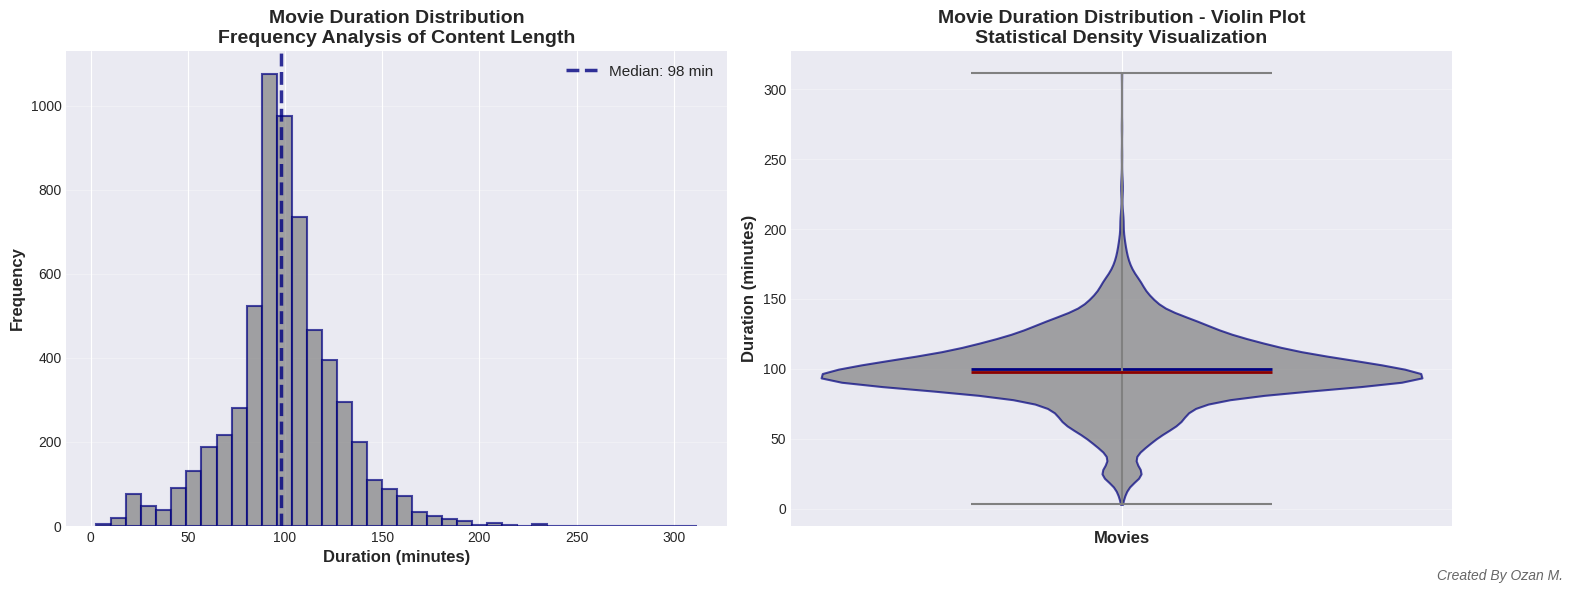

In [13]:
movies_df = df[df['type'] == 'Movie'].copy()
movies_df['duration_min'] = movies_df['duration'].str.extract('(\d+)').astype(float)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram
axes[0].hist(movies_df['duration_min'].dropna(), bins=40, color='gray', 
             alpha=0.7, edgecolor='navy', linewidth=1.5)
axes[0].axvline(movies_df['duration_min'].median(), color='navy', 
                linestyle='--', linewidth=2.5, label=f"Median: {movies_df['duration_min'].median():.0f} min", alpha=0.8)
axes[0].set_title('Movie Duration Distribution\nFrequency Analysis of Content Length', 
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Duration (minutes)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# Violin plot
parts = axes[1].violinplot([movies_df['duration_min'].dropna()], 
                           positions=[0], widths=0.7, showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('gray')
    pc.set_alpha(0.7)
    pc.set_edgecolor('navy')
    pc.set_linewidth(1.5)

parts['cmeans'].set_color('navy')
parts['cmedians'].set_color('darkred')
parts['cmeans'].set_linewidth(2)
parts['cmedians'].set_linewidth(2)

axes[1].set_title('Movie Duration Distribution - Violin Plot\nStatistical Density Visualization', 
                  fontsize=14, fontweight='bold')
axes[1].set_ylabel('Duration (minutes)', fontsize=12, fontweight='bold')
axes[1].set_xticks([0])
axes[1].set_xticklabels(['Movies'], fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
 TV Show Season Analysis
</h1>

**Series Length Patterns:**
- **Single Season Dominance:** Majority of shows have 1-2 seasons indicating high experimentation and limited series format
- **Long-running Shows:** Presence of 5+ season shows demonstrates successful franchises and viewer loyalty
- **Cancellation Strategy:** Short season counts suggest Netflix's data-driven renewal decisions and risk management

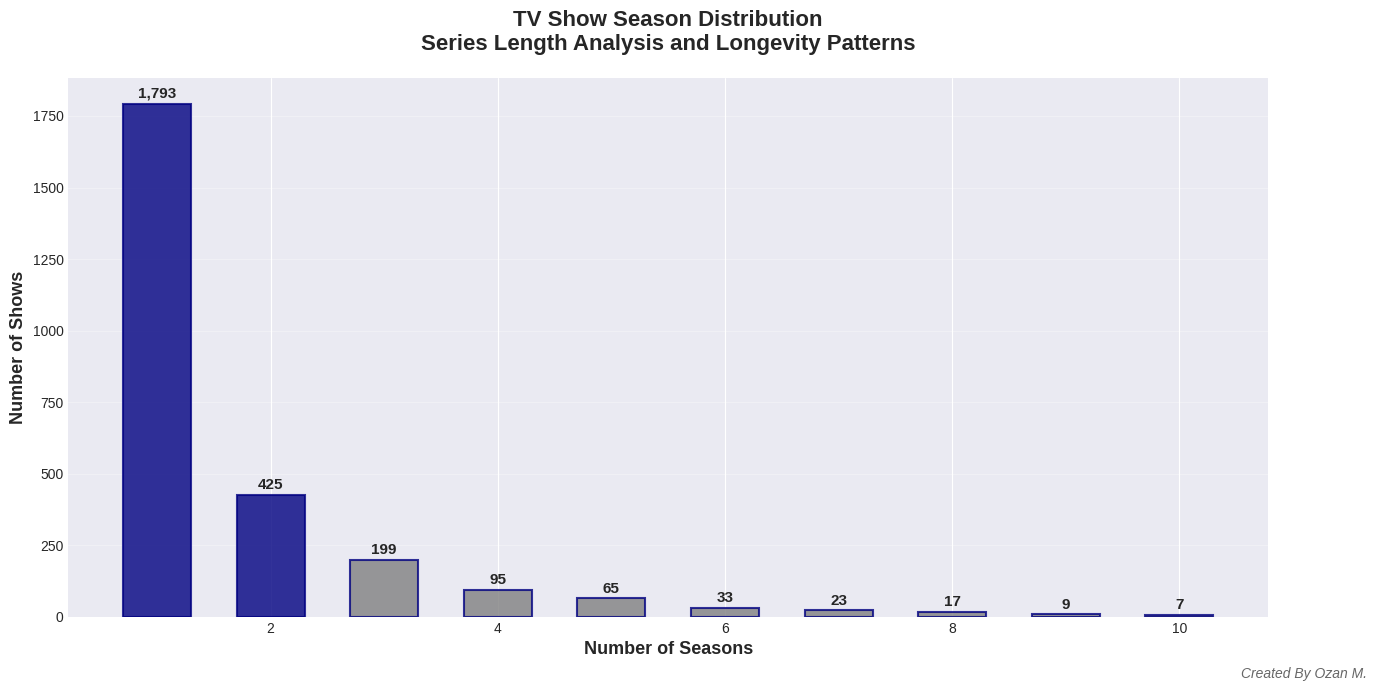

In [14]:
tv_shows_df = df[df['type'] == 'TV Show'].copy()
tv_shows_df['num_seasons'] = tv_shows_df['duration'].str.extract('(\d+)').astype(float)
season_dist = tv_shows_df['num_seasons'].value_counts().sort_index().head(10)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(season_dist.index, season_dist.values, 
              color=['navy' if x <= 2 else 'gray' for x in season_dist.index], 
              alpha=0.8, edgecolor='navy', linewidth=1.5, width=0.6)

ax.set_title('TV Show Season Distribution\nSeries Length Analysis and Longevity Patterns', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Number of Seasons', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Shows', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

for bar, v in zip(bars, season_dist.values):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{int(v):,}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<h1 style="font-size:50px; font-family:Garamond; font-weight:normal; background-color:#1e3a8a; color:white; text-align:center; border-radius:100px 100px; padding:20px;">
 Content Release Decades Evolution
</h1>

**Historical Content Perspective:**
- **Modern Content Focus:** 2010s and 2020s dominate reflecting Netflix's preference for recent productions
- **Classic Catalog:** Significant presence of 1990s-2000s content shows nostalgic appeal and library depth
- **Acquisition Strategy:** Decade distribution reveals balance between new originals and licensed classic content

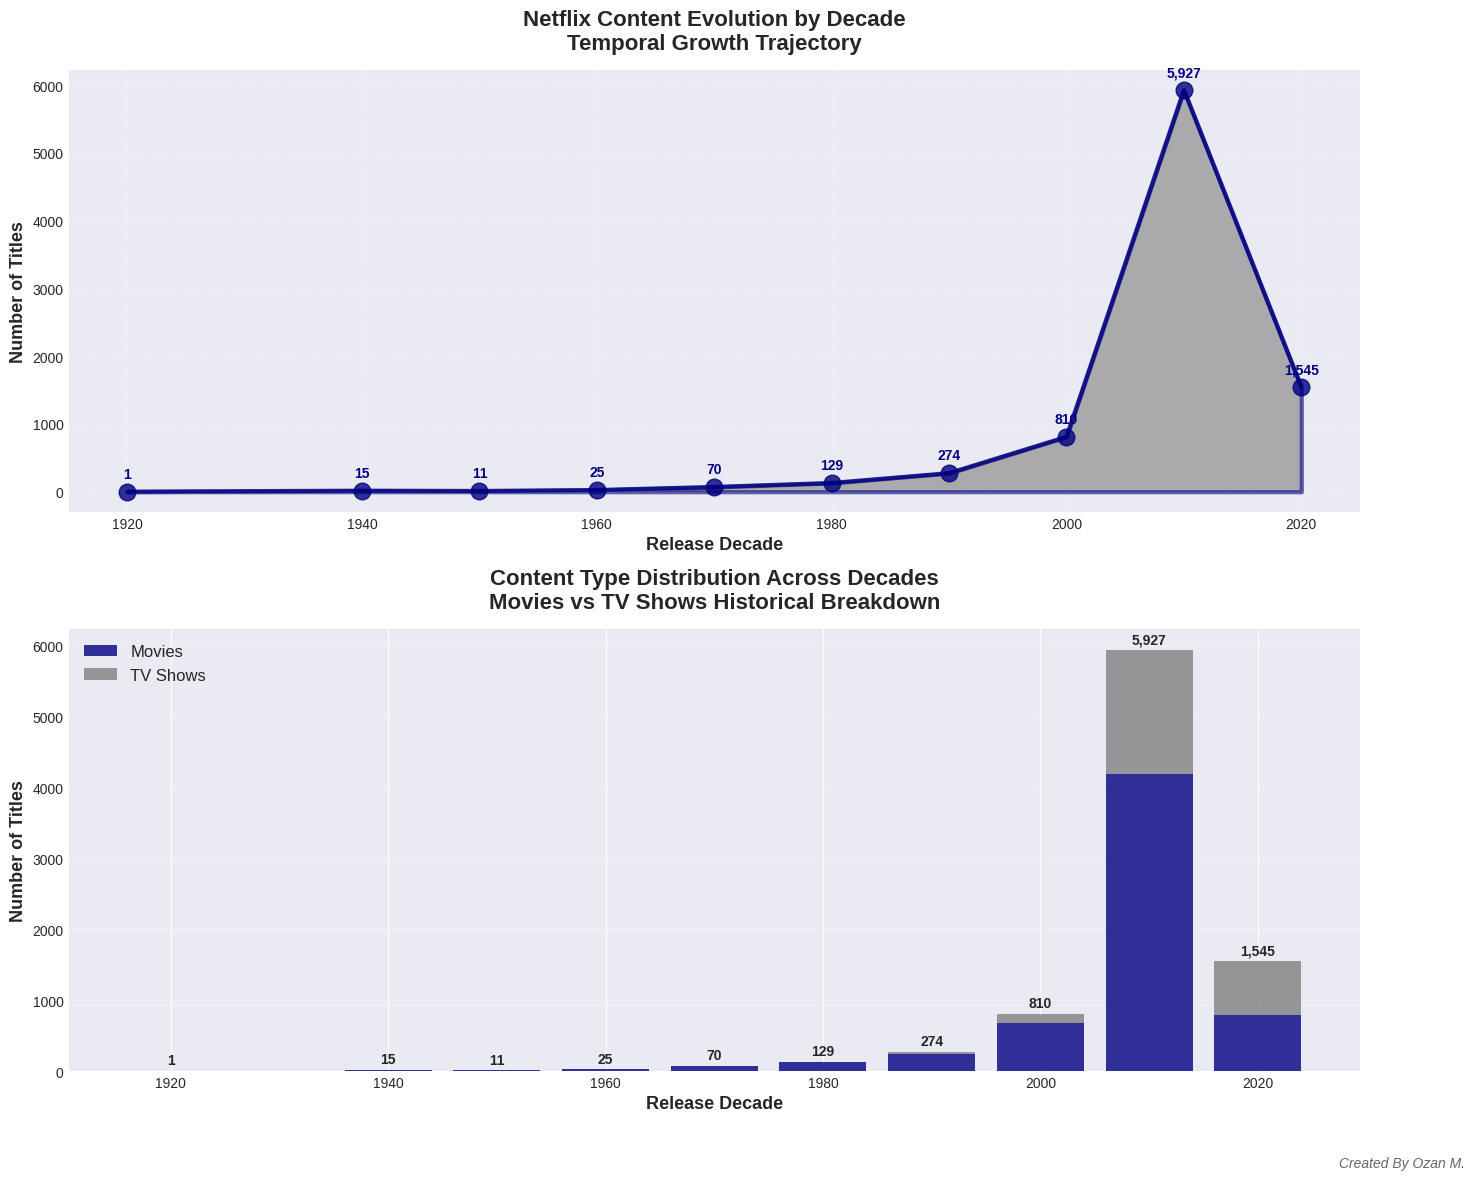

In [15]:
df['decade'] = (df['release_year'] // 10) * 10
decade_counts = df['decade'].value_counts().sort_index()
decade_labels = [f"{int(d)}s" for d in decade_counts.index]

fig, axes = plt.subplots(2, 1, figsize=(15, 12))

# Area Chart
axes[0].fill_between(decade_counts.index, decade_counts.values, 
                     alpha=0.6, color='gray', edgecolor='navy', linewidth=3)
axes[0].plot(decade_counts.index, decade_counts.values, 
            marker='o', markersize=12, color='navy', linewidth=3, alpha=0.8)

axes[0].set_title('Netflix Content Evolution by Decade\nTemporal Growth Trajectory', 
                 fontsize=16, fontweight='bold', pad=15)
axes[0].set_xlabel('Release Decade', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Titles', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, linestyle='--')

for x, y in zip(decade_counts.index, decade_counts.values):
    axes[0].annotate(f'{int(y):,}', xy=(x, y), xytext=(0, 10), 
                    textcoords='offset points', ha='center', fontsize=10, 
                    fontweight='bold', color='navy')

# Stacked comparison by type
decade_type = pd.crosstab(df['decade'], df['type'])
decade_type = decade_type.reindex(decade_counts.index, fill_value=0)

axes[1].bar(decade_type.index, decade_type['Movie'], 
           label='Movies', color='navy', alpha=0.8, width=8)
axes[1].bar(decade_type.index, decade_type['TV Show'], 
           bottom=decade_type['Movie'], label='TV Shows', color='gray', alpha=0.8, width=8)

axes[1].set_title('Content Type Distribution Across Decades\nMovies vs TV Shows Historical Breakdown', 
                 fontsize=16, fontweight='bold', pad=15)
axes[1].set_xlabel('Release Decade', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Number of Titles', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=12, loc='upper left')
axes[1].grid(axis='y', alpha=0.3)

for idx in decade_type.index:
    total = decade_type.loc[idx].sum()
    axes[1].text(idx, total + 50, f'{int(total):,}', 
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.text(0.98, 0.02, 'Created By Ozan M.', 
         transform=fig.transFigure, fontsize=10, 
         verticalalignment='bottom', horizontalalignment='right',
         alpha=0.7, style='italic')

plt.tight_layout()
plt.show()

<div style="background-color: #1e3a8a; color: white; padding: 30px; border-radius: 20px; text-align: center; margin-top: 50px;">
     <h2 style="font-size: 36px; font-family: Garamond; margin-bottom: 20px;">🎉 Thank You For Reviewing! 🎉</h2>
     <p style="font-size: 16px; line-height: 1.8;">
         🙏 <strong>Thank you so much for your support and interest!</strong> 🙏<br>
         I am grateful to each and every one of you for taking your valuable time to review this Netflix analysis project.<br>
         I hope the visualizations and insights provided were useful and met your expectations. 🚀
     </p>
     <p style="font-size: 16px; margin-top: 20px;">
         💡 <strong>If you have any questions or feedback, please feel free to reach out!</strong> 💡
     </p>
     <p style="font-size: 16px; margin-top: 20px;">
         🔗 <strong>See you in the next project!</strong> 🔗
     </p>
     <hr style="border: 1px solid white; margin: 20px 0;">
     <p style="font-size: 14px; font-style: italic; opacity: 0.9;">
         Created By <strong>Ozan M.</strong> | Netflix Dataset Comprehensive Analysis
     </p>
</div>